In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch: 2.11.0
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [2]:
# PDG vocabulary information from Notebook 02.
#
# Notebook 02 found 31 unique final-state PDG IDs.
# Token 0 is reserved for padding/unknown.

PAD_ID = 0
VOCAB_SIZE = 32

print("Padding token:", PAD_ID)
print("Vocabulary size:", VOCAB_SIZE)

Padding token: 0
Vocabulary size: 32


In [3]:
# Load the processed dataset from Notebook 02.

DATA_FILE = "processed_collider_events.pt"

data = torch.load(
    DATA_FILE,
    weights_only=False
)

continuous_list = data["continuous_list"]
pdg_id_list = data["pdg_id_list"]

train_idx = data["train_idx"]
val_idx = data["val_idx"]
test_idx = data["test_idx"]

feature_mean = data["feature_mean"]
feature_std = data["feature_std"]

pdg_to_id = data["pdg_to_id"]

PAD_ID = data["PAD_ID"]
VOCAB_SIZE = data["VOCAB_SIZE"]

print("Processed dataset loaded.")
print("Events:", len(continuous_list))
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Vocabulary size:", VOCAB_SIZE)

Processed dataset loaded.
Events: 45830
Train: 36664
Validation: 4583
Test: 4583
Vocabulary size: 32


# Recreate the Dataset class

In [4]:
class ColliderEventDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        event_indices,
        feature_lists,
        pdg_lists,
        mean,
        std
    ):
        self.event_indices = np.asarray(event_indices)
        self.feature_lists = feature_lists
        self.pdg_lists = pdg_lists

        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)

    def __len__(self):
        return len(self.event_indices)

    def __getitem__(self, idx):

        event_index = int(self.event_indices[idx])

        rows = []

        for p in self.feature_lists[event_index]:

            rows.append([
                p["log_pt"],
                p["eta"],
                p["sin_phi"],
                p["cos_phi"],
                p["log_energy"],
                p["log_mass"],
                p["charge"]
            ])

        features = np.asarray(rows, dtype=np.float32)

        features = (features - self.mean) / self.std

        pdg_tokens = np.asarray(
            self.pdg_lists[event_index],
            dtype=np.int64
        )

        return {
            "features": torch.from_numpy(features),
            "pdg": torch.from_numpy(pdg_tokens)
        }

# Recreate the collate function

In [5]:
def collate_events(batch):

    lengths = torch.tensor(
        [item["features"].shape[0] for item in batch],
        dtype=torch.long
    )

    features = torch.nn.utils.rnn.pad_sequence(
        [item["features"] for item in batch],
        batch_first=True,
        padding_value=0.0
    )

    pdg = torch.nn.utils.rnn.pad_sequence(
        [item["pdg"] for item in batch],
        batch_first=True,
        padding_value=PAD_ID
    )

    padding_mask = (
        torch.arange(features.shape[1])[None, :]
        >= lengths[:, None]
    )

    return {
        "features": features,
        "pdg": pdg,
        "padding_mask": padding_mask,
        "lengths": lengths
    }

# Create the loader

In [6]:
train_dataset = ColliderEventDataset(
    train_idx,
    continuous_list,
    pdg_id_list,
    feature_mean,
    feature_std
)

val_dataset = ColliderEventDataset(
    val_idx,
    continuous_list,
    pdg_id_list,
    feature_mean,
    feature_std
)

test_dataset = ColliderEventDataset(
    test_idx,
    continuous_list,
    pdg_id_list,
    feature_mean,
    feature_std
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_events
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_events
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_events
)

# Creat batch

In [7]:
batch = next(iter(train_loader))

print("features:", batch["features"].shape)
print("pdg:", batch["pdg"].shape)
print("padding mask:", batch["padding_mask"].shape)
print("lengths:", batch["lengths"][:10])

features: torch.Size([64, 120, 7])
pdg: torch.Size([64, 120])
padding mask: torch.Size([64, 120])
lengths: tensor([101, 101,  99,  86, 120,  86,  77,  92,  79,  90])


In [8]:
assert batch["features"].ndim == 3
assert batch["features"].shape[2] == 7
assert batch["pdg"].shape[:2] == batch["features"].shape[:2]
assert batch["padding_mask"].shape == batch["pdg"].shape
assert torch.isfinite(batch["features"]).all()

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Model configuration

In [9]:
FEATURE_DIM = 7

D_MODEL = 128
N_HEADS = 8
N_LAYERS = 4
DIM_FEEDFORWARD = 512
DROPOUT = 0.1

MASK_RATIO = 0.40


print("Feature dimension:", FEATURE_DIM)
print("Model dimension:", D_MODEL)
print("Transformer layers:", N_LAYERS)
print("Attention heads:", N_HEADS)
print("Vocabulary size:", VOCAB_SIZE)
print("Mask ratio:", MASK_RATIO)

Feature dimension: 7
Model dimension: 128
Transformer layers: 4
Attention heads: 8
Vocabulary size: 32
Mask ratio: 0.4


# Masking function

In [10]:
def create_mask(padding_mask, mask_ratio=0.40):
    """
    Randomly mask valid particles in each event.

    padding_mask:
        [batch, sequence]
        True  = padding
        False = real particle
    """

    batch_size, seq_len = padding_mask.shape

    mask = torch.zeros_like(padding_mask, dtype=torch.bool)

    for b in range(batch_size):
        valid_positions = torch.where(~padding_mask[b])[0]

        n_valid = len(valid_positions)

        if n_valid == 0:
            continue

        n_mask = max(1, int(mask_ratio * n_valid))

        selected = torch.randperm(n_valid, device=padding_mask.device)[:n_mask]

        mask[b, valid_positions[selected]] = True

    return mask

# Test the masking

In [11]:
mask = create_mask(
    batch["padding_mask"].to(device),
    mask_ratio=MASK_RATIO
)

print("Batch shape:", batch["features"].shape)
print("Mask shape:", mask.shape)

print("Masked particles:", mask.sum().item())
print("Real particles:", (~batch["padding_mask"].to(device)).sum().item())

Batch shape: torch.Size([64, 120, 7])
Mask shape: torch.Size([64, 120])
Masked particles: 2013
Real particles: 5092


In [12]:
mask_fraction = (
    mask.sum().item()
    / (~batch["padding_mask"].to(device)).sum().item()
)

print("Actual mask fraction:", mask_fraction)

Actual mask fraction: 0.39532600157109193


# Build the particle embedding

In [13]:
class ParticleEmbedding(nn.Module):

    def __init__(self, feature_dim, vocab_size, d_model):
        super().__init__()

        self.feature_embedding = nn.Sequential(
            nn.Linear(feature_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )

        self.pdg_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_ID
        )

        self.mask_token = nn.Parameter(
            torch.randn(d_model) * 0.02
        )

    def forward(self, features, pdg, mask):
        """
        features: [B, N, 7]
        pdg:      [B, N]
        mask:     [B, N]
        """

        feature_emb = self.feature_embedding(features)

        pdg_emb = self.pdg_embedding(pdg)

        x = feature_emb + pdg_emb

        # Replace masked particle representations
        # with a learned [MASK] token.
        x = torch.where(
            mask.unsqueeze(-1),
            self.mask_token.view(1, 1, -1),
            x
        )

        return x

# Transformer

In [14]:
class MaskedParticleTransformer(nn.Module):

    def __init__(
        self,
        feature_dim,
        vocab_size,
        d_model=128,
        n_heads=8,
        n_layers=4,
        dim_feedforward=512,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = ParticleEmbedding(
            feature_dim=feature_dim,
            vocab_size=vocab_size,
            d_model=d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        # Predict the seven continuous particle features.
        self.feature_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, feature_dim)
        )

        # Predict PDG token.
        self.pdg_head = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, features, pdg, padding_mask, mask):

        x = self.embedding(
            features,
            pdg,
            mask
        )

        x = self.transformer(
            x,
            src_key_padding_mask=padding_mask
        )

        predicted_features = self.feature_head(x)

        predicted_pdg = self.pdg_head(x)

        return predicted_features, predicted_pdg

# Instantiate the model

In [15]:
model = MaskedParticleTransformer(
    feature_dim=FEATURE_DIM,
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(device)

print(model)

MaskedParticleTransformer(
  (embedding): ParticleEmbedding(
    (feature_embedding): Sequential(
      (0): Linear(in_features=7, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (pdg_embedding): Embedding(32, 128, padding_idx=0)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1,

/tmp/ipykernel_633/2846961799.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [16]:
n_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_parameters:,}")

Trainable parameters: 836,391


# First forward pass

In [17]:
features = batch["features"].to(device)
pdg = batch["pdg"].to(device)
padding_mask = batch["padding_mask"].to(device)

mask = create_mask(
    padding_mask,
    mask_ratio=MASK_RATIO
)

pred_features, pred_pdg = model(
    features,
    pdg,
    padding_mask,
    mask
)

print("Input features :", features.shape)
print("Pred features  :", pred_features.shape)
print("Input PDG      :", pdg.shape)
print("Pred PDG logits:", pred_pdg.shape)
print("Mask           :", mask.shape)

Input features : torch.Size([64, 120, 7])
Pred features  : torch.Size([64, 120, 7])
Input PDG      : torch.Size([64, 120])
Pred PDG logits: torch.Size([64, 120, 32])
Mask           : torch.Size([64, 120])


# Masked reconstruction loss

In [18]:
def masked_reconstruction_loss(
    pred_features,
    pred_pdg,
    target_features,
    target_pdg,
    mask,
):
    """
    Compute reconstruction loss only for masked particles.

    pred_features: [B, N, 7]
    pred_pdg:      [B, N, vocab_size]
    target_features: [B, N, 7]
    target_pdg:      [B, N]
    mask:            [B, N]
    """

    # Make sure only real masked particles contribute.
    masked_features_pred = pred_features[mask]
    masked_features_target = target_features[mask]

    masked_pdg_pred = pred_pdg[mask]
    masked_pdg_target = target_pdg[mask]

    # Continuous feature reconstruction.
    feature_loss = F.mse_loss(
        masked_features_pred,
        masked_features_target
    )

    # Categorical PDG reconstruction.
    pdg_loss = F.cross_entropy(
        masked_pdg_pred,
        masked_pdg_target
    )

    total_loss = feature_loss + pdg_loss

    return total_loss, feature_loss, pdg_loss

In [19]:
target_features = features
target_pdg = pdg

loss, feature_loss, pdg_loss = masked_reconstruction_loss(
    pred_features,
    pred_pdg,
    target_features,
    target_pdg,
    mask
)

print("Total loss   :", loss.item())
print("Feature loss :", feature_loss.item())
print("PDG loss     :", pdg_loss.item())

Total loss   : 5.005565166473389
Feature loss : 1.0575565099716187
PDG loss     : 3.9480085372924805


In [20]:
print("Masked particles used for loss:", mask.sum().item())
print("Feature values per masked particle:", FEATURE_DIM)

Masked particles used for loss: 2013
Feature values per masked particle: 7


# Optimizer

In [21]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

Learning rate: 0.0001
Weight decay: 0.0001


In [22]:
model.train()

optimizer.zero_grad()

# Move batch to GPU.
features = batch["features"].to(device)
pdg = batch["pdg"].to(device)
padding_mask = batch["padding_mask"].to(device)

# Create a fresh random mask.
mask = create_mask(
    padding_mask,
    mask_ratio=MASK_RATIO
)

# Forward pass.
pred_features, pred_pdg = model(
    features,
    pdg,
    padding_mask,
    mask
)

# Reconstruction loss.
loss, feature_loss, pdg_loss = masked_reconstruction_loss(
    pred_features,
    pred_pdg,
    features,
    pdg,
    mask
)

# Backpropagation.
loss.backward()

# Update model parameters.
optimizer.step()

print("Training step completed.")
print("Total loss   :", loss.item())
print("Feature loss :", feature_loss.item())
print("PDG loss     :", pdg_loss.item())

Training step completed.
Total loss   : 5.018678665161133
Feature loss : 1.0650556087493896
PDG loss     : 3.9536232948303223


In [23]:
gradient_norm = 0.0

for parameter in model.parameters():
    if parameter.grad is not None:
        gradient_norm += parameter.grad.detach().norm().item() ** 2

gradient_norm = gradient_norm ** 0.5

print("Gradient norm:", gradient_norm)

Gradient norm: 16.166370288640888


In [24]:
# ============================================================
# Training configuration
# ============================================================

EPOCHS = 30

CHECKPOINT_DIR = "checkpoints"
BEST_CHECKPOINT = f"{CHECKPOINT_DIR}/best_model.pt"
LAST_CHECKPOINT = f"{CHECKPOINT_DIR}/last_model.pt"

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Epochs:", EPOCHS)
print("Checkpoint directory:", CHECKPOINT_DIR)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Epochs: 30
Checkpoint directory: checkpoints
Training batches: 573
Validation batches: 72


In [25]:
# ============================================================
# Validation
# ============================================================

@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    total_loss = 0.0
    total_feature_loss = 0.0
    total_pdg_loss = 0.0
    total_masked_particles = 0

    for batch in loader:

        features = batch["features"].to(device)
        pdg = batch["pdg"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        # Fresh random mask for validation
        mask = create_mask(
            padding_mask,
            mask_ratio=MASK_RATIO
        )

        pred_features, pred_pdg = model(
            features,
            pdg,
            padding_mask,
            mask
        )

        loss, feature_loss, pdg_loss = masked_reconstruction_loss(
            pred_features,
            pred_pdg,
            features,
            pdg,
            mask
        )

        n_masked = mask.sum().item()

        if n_masked == 0:
            continue

        total_loss += loss.item() * n_masked
        total_feature_loss += feature_loss.item() * n_masked
        total_pdg_loss += pdg_loss.item() * n_masked

        total_masked_particles += n_masked

    if total_masked_particles == 0:
        return float("nan"), float("nan"), float("nan")

    return (
        total_loss / total_masked_particles,
        total_feature_loss / total_masked_particles,
        total_pdg_loss / total_masked_particles
    )

In [26]:
# ============================================================
# Full training loop with checkpointing
# ============================================================

train_losses = []
val_losses = []

train_feature_losses = []
val_feature_losses = []

train_pdg_losses = []
val_pdg_losses = []

best_val_loss = float("inf")
best_epoch = 0

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    running_feature_loss = 0.0
    running_pdg_loss = 0.0

    total_masked_particles = 0

    for batch_idx, batch in enumerate(train_loader):

        features = batch["features"].to(device)
        pdg = batch["pdg"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        # ----------------------------------------------------
        # Create random mask
        # ----------------------------------------------------

        mask = create_mask(
            padding_mask,
            mask_ratio=MASK_RATIO
        )

        optimizer.zero_grad(set_to_none=True)

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        pred_features, pred_pdg = model(
            features,
            pdg,
            padding_mask,
            mask
        )

        # ----------------------------------------------------
        # Masked reconstruction loss
        # ----------------------------------------------------

        loss, feature_loss, pdg_loss = masked_reconstruction_loss(
            pred_features,
            pred_pdg,
            features,
            pdg,
            mask
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        # Optional gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # ----------------------------------------------------
        # Accumulate losses
        # ----------------------------------------------------

        n_masked = mask.sum().item()

        if n_masked == 0:
            continue

        running_loss += loss.item() * n_masked
        running_feature_loss += feature_loss.item() * n_masked
        running_pdg_loss += pdg_loss.item() * n_masked

        total_masked_particles += n_masked

    # --------------------------------------------------------
    # Average training losses
    # --------------------------------------------------------

    epoch_train_loss = (
        running_loss / total_masked_particles
    )

    epoch_train_feature_loss = (
        running_feature_loss / total_masked_particles
    )

    epoch_train_pdg_loss = (
        running_pdg_loss / total_masked_particles
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    (
        epoch_val_loss,
        epoch_val_feature_loss,
        epoch_val_pdg_loss
    ) = evaluate(
        model,
        val_loader
    )

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_feature_losses.append(epoch_train_feature_loss)
    val_feature_losses.append(epoch_val_feature_loss)

    train_pdg_losses.append(epoch_train_pdg_loss)
    val_pdg_losses.append(epoch_val_pdg_loss)

    # --------------------------------------------------------
    # Checkpoint: last epoch
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),

            "train_loss": epoch_train_loss,
            "val_loss": epoch_val_loss,

            "train_feature_loss": epoch_train_feature_loss,
            "val_feature_loss": epoch_val_feature_loss,

            "train_pdg_loss": epoch_train_pdg_loss,
            "val_pdg_loss": epoch_val_pdg_loss,

            "train_losses": train_losses,
            "val_losses": val_losses,

            "train_feature_losses": train_feature_losses,
            "val_feature_losses": val_feature_losses,

            "train_pdg_losses": train_pdg_losses,
            "val_pdg_losses": val_pdg_losses,

            "config": {
                "feature_dim": FEATURE_DIM,
                "d_model": D_MODEL,
                "n_heads": N_HEADS,
                "n_layers": N_LAYERS,
                "dim_feedforward": DIM_FEEDFORWARD,
                "dropout": DROPOUT,
                "mask_ratio": MASK_RATIO,
            }
        },
        LAST_CHECKPOINT
    )

    # --------------------------------------------------------
    # Best-model checkpoint
    # --------------------------------------------------------

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),

                "val_loss": epoch_val_loss,
                "feature_loss": epoch_val_feature_loss,
                "pdg_loss": epoch_val_pdg_loss,

                "train_losses": train_losses,
                "val_losses": val_losses,

                "train_feature_losses": train_feature_losses,
                "val_feature_losses": val_feature_losses,

                "train_pdg_losses": train_pdg_losses,
                "val_pdg_losses": val_pdg_losses,

                "config": {
                    "feature_dim": FEATURE_DIM,
                    "d_model": D_MODEL,
                    "n_heads": N_HEADS,
                    "n_layers": N_LAYERS,
                    "dim_feedforward": DIM_FEEDFORWARD,
                    "dropout": DROPOUT,
                    "mask_ratio": MASK_RATIO,
                }
            },
            BEST_CHECKPOINT
        )

        best_marker = "  <-- BEST"
    else:
        best_marker = ""

    # --------------------------------------------------------
    # Print progress
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train: {epoch_train_loss:.4f} | "
        f"Val: {epoch_val_loss:.4f} | "
        f"Feature: {epoch_val_feature_loss:.4f} | "
        f"PDG: {epoch_val_pdg_loss:.4f}"
        f"{best_marker}"
    )

print()
print("Training finished.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Last checkpoint:", LAST_CHECKPOINT)
print("Best checkpoint:", BEST_CHECKPOINT)

Epoch 01/30 | Train: 2.5860 | Val: 2.5381 | Feature: 0.9895 | PDG: 1.5486  <-- BEST
Epoch 02/30 | Train: 2.5364 | Val: 2.5276 | Feature: 0.9891 | PDG: 1.5385  <-- BEST
Epoch 03/30 | Train: 2.5306 | Val: 2.5299 | Feature: 0.9894 | PDG: 1.5405
Epoch 04/30 | Train: 2.5250 | Val: 2.5263 | Feature: 0.9908 | PDG: 1.5355  <-- BEST
Epoch 05/30 | Train: 2.5205 | Val: 2.5175 | Feature: 0.9861 | PDG: 1.5314  <-- BEST
Epoch 06/30 | Train: 2.5209 | Val: 2.5231 | Feature: 0.9885 | PDG: 1.5346
Epoch 07/30 | Train: 2.5189 | Val: 2.5242 | Feature: 0.9889 | PDG: 1.5353
Epoch 08/30 | Train: 2.5191 | Val: 2.5248 | Feature: 0.9914 | PDG: 1.5333
Epoch 09/30 | Train: 2.5174 | Val: 2.5193 | Feature: 0.9869 | PDG: 1.5323
Epoch 10/30 | Train: 2.5150 | Val: 2.5196 | Feature: 0.9881 | PDG: 1.5315
Epoch 11/30 | Train: 2.5178 | Val: 2.5268 | Feature: 0.9903 | PDG: 1.5365
Epoch 12/30 | Train: 2.5159 | Val: 2.5160 | Feature: 0.9852 | PDG: 1.5309  <-- BEST
Epoch 13/30 | Train: 2.5112 | Val: 2.5234 | Feature: 0.9865 | 

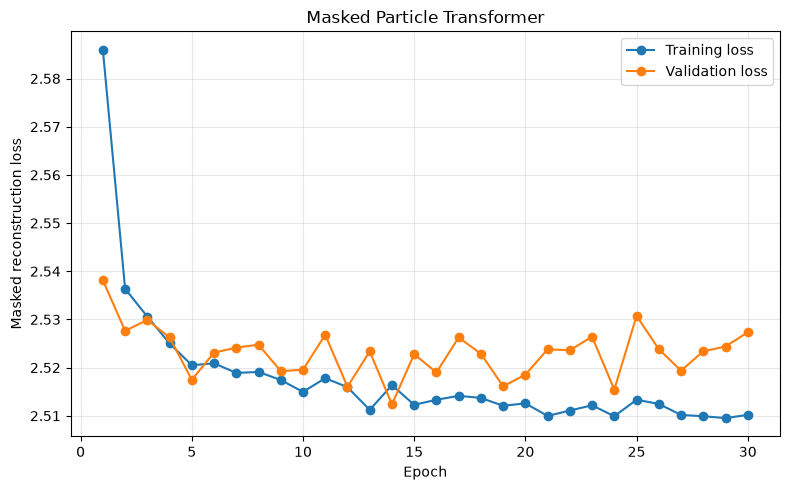

In [27]:
# ============================================================
# Plot training / validation losses
# ============================================================

epochs = np.arange(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Masked reconstruction loss")
plt.title("Masked Particle Transformer")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

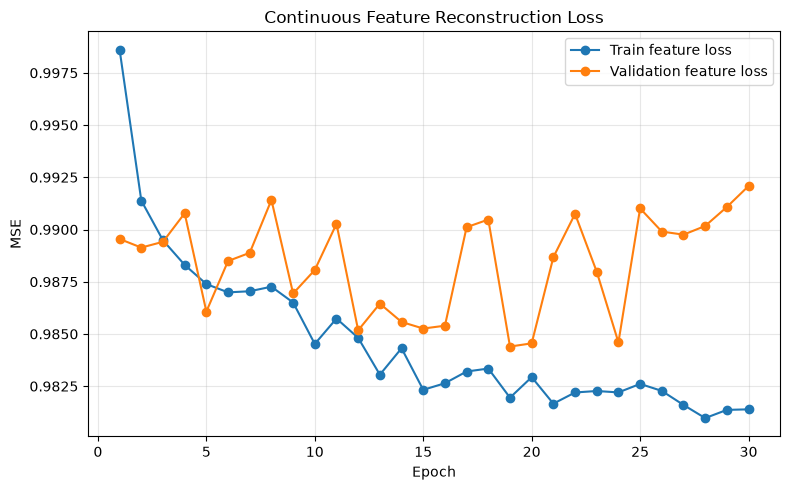

In [28]:
# ============================================================
# Feature reconstruction loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_feature_losses,
    marker="o",
    label="Train feature loss"
)

plt.plot(
    epochs,
    val_feature_losses,
    marker="o",
    label="Validation feature loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Continuous Feature Reconstruction Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

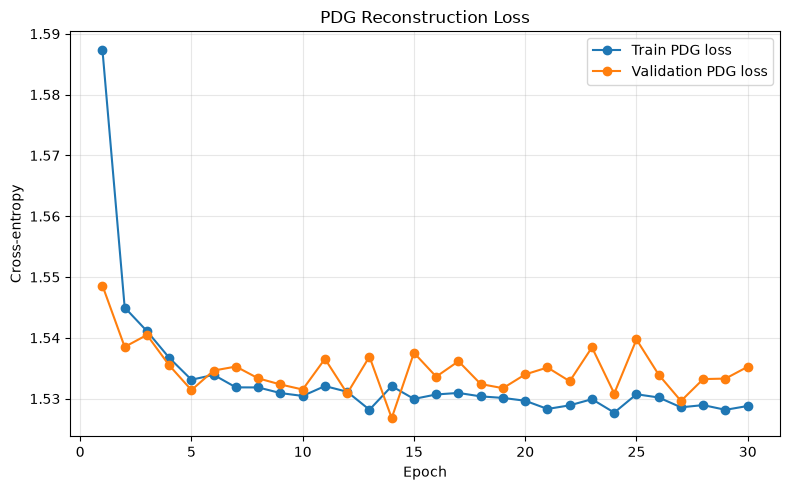

In [29]:
# ============================================================
# PDG reconstruction loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_pdg_losses,
    marker="o",
    label="Train PDG loss"
)

plt.plot(
    epochs,
    val_pdg_losses,
    marker="o",
    label="Validation PDG loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")
plt.title("PDG Reconstruction Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Load best checkpoint
# ============================================================

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best checkpoint loaded.")
print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Feature loss:", checkpoint["feature_loss"])
print("PDG loss:", checkpoint["pdg_loss"])

Best checkpoint loaded.
Epoch: 14
Validation loss: 2.5123797287158913
Feature loss: 0.9855745559300371
PDG loss: 1.526805171841866


In [31]:
import os

print("Checkpoint files:")

for filename in os.listdir(CHECKPOINT_DIR):
    path = os.path.join(CHECKPOINT_DIR, filename)

    print(
        filename,
        f"{os.path.getsize(path) / 1024**2:.2f} MB"
    )

Checkpoint files:
best_model.pt 9.64 MB
last_model.pt 9.64 MB



# Validation: evaluate best model on the validation set


In [37]:
model.eval()

val_total_loss = 0.0
val_feature_loss = 0.0
val_pdg_loss = 0.0

total_masked_particles = 0

with torch.no_grad():

    for batch in val_loader:

        # ----------------------------------------------------
        # Get batch
        # ----------------------------------------------------

        features = batch["features"].to(device)
        pdg = batch["pdg"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        # ----------------------------------------------------
        # Create a fresh validation mask
        # ----------------------------------------------------

        mask = create_mask(
            padding_mask,
            mask_ratio=MASK_RATIO
        )

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        feature_pred, pdg_logits = model(
            features,
            pdg,
            padding_mask,
            mask
        )

        # ----------------------------------------------------
        # Calculate masked reconstruction losses
        # ----------------------------------------------------

        loss, feature_loss, pdg_loss = masked_reconstruction_loss(
            feature_pred,
            pdg_logits,
            features,
            pdg,
            mask
        )

        # ----------------------------------------------------
        # Number of masked particles
        # ----------------------------------------------------

        n_masked = mask.sum().item()

        if n_masked == 0:
            continue

        # ----------------------------------------------------
        # Accumulate weighted losses
        # ----------------------------------------------------

        val_total_loss += loss.item() * n_masked
        val_feature_loss += feature_loss.item() * n_masked
        val_pdg_loss += pdg_loss.item() * n_masked

        total_masked_particles += n_masked


# ------------------------------------------------------------
# Average over masked particles
# ------------------------------------------------------------

val_total_loss /= total_masked_particles
val_feature_loss /= total_masked_particles
val_pdg_loss /= total_masked_particles


# ============================================================
# Print results
# ============================================================

print("=" * 60)
print("BEST MODEL VALIDATION")
print("=" * 60)

print(f"Validation total loss   : {val_total_loss:.6f}")
print(f"Validation feature loss : {val_feature_loss:.6f}")
print(f"Validation PDG loss     : {val_pdg_loss:.6f}")

print(f"Masked particles        : {total_masked_particles:,}")

print("=" * 60)

BEST MODEL VALIDATION
Validation total loss   : 2.520477
Validation feature loss : 0.986826
Validation PDG loss     : 1.533651
Masked particles        : 145,667


In [38]:
# ============================================================
# Inspect one validation batch
# ============================================================

model.eval()

batch = next(iter(val_loader))

print("Batch type:", type(batch))

if isinstance(batch, dict):
    print("Batch keys:", batch.keys())

    for key, value in batch.items():
        print(
            f"{key}: type={type(value)}, "
            f"shape={getattr(value, 'shape', None)}, "
            f"dtype={getattr(value, 'dtype', None)}"
        )

elif isinstance(batch, (tuple, list)):
    print("Number of elements:", len(batch))

    for i, value in enumerate(batch):
        print(
            f"[{i}]: type={type(value)}, "
            f"shape={getattr(value, 'shape', None)}, "
            f"dtype={getattr(value, 'dtype', None)}"
        )

else:
    print(batch)

Batch type: <class 'dict'>
Batch keys: dict_keys(['features', 'pdg', 'padding_mask', 'lengths'])
features: type=<class 'torch.Tensor'>, shape=torch.Size([64, 130, 7]), dtype=torch.float32
pdg: type=<class 'torch.Tensor'>, shape=torch.Size([64, 130]), dtype=torch.int64
padding_mask: type=<class 'torch.Tensor'>, shape=torch.Size([64, 130]), dtype=torch.bool
lengths: type=<class 'torch.Tensor'>, shape=torch.Size([64]), dtype=torch.int64


In [39]:
# ============================================================
# Find the masking function / masking variables
# ============================================================

import inspect

print("Objects related to masking:")
for name in dir():
    if "mask" in name.lower():
        obj = globals()[name]
        print(name, type(obj))

print("\nModel forward signature:")
print(inspect.signature(model.forward))

Objects related to masking:
MASK_RATIO <class 'float'>
MaskedParticleTransformer <class 'type'>
create_mask <class 'function'>
mask <class 'torch.Tensor'>
mask_fraction <class 'float'>
masked_reconstruction_loss <class 'function'>
n_masked <class 'int'>
padding_mask <class 'torch.Tensor'>
total_masked_particles <class 'int'>

Model forward signature:
(features, pdg, padding_mask, mask)


In [40]:
# ============================================================
# Inspect the objects that look like masking functions
# ============================================================

for name in dir():
    if "mask" in name.lower():
        obj = globals()[name]

        if callable(obj):
            print("\n" + "="*60)
            print("FUNCTION:", name)
            print(inspect.signature(obj))
            try:
                print(inspect.getsource(obj))
            except Exception as e:
                print("Source unavailable:", e)


FUNCTION: MaskedParticleTransformer
(feature_dim, vocab_size, d_model=128, n_heads=8, n_layers=4, dim_feedforward=512, dropout=0.1)
Source unavailable: source code not available

FUNCTION: create_mask
(padding_mask, mask_ratio=0.4)
def create_mask(padding_mask, mask_ratio=0.40):
    """
    Randomly mask valid particles in each event.

    padding_mask:
        [batch, sequence]
        True  = padding
        False = real particle
    """

    batch_size, seq_len = padding_mask.shape

    mask = torch.zeros_like(padding_mask, dtype=torch.bool)

    for b in range(batch_size):
        valid_positions = torch.where(~padding_mask[b])[0]

        n_valid = len(valid_positions)

        if n_valid == 0:
            continue

        n_mask = max(1, int(mask_ratio * n_valid))

        selected = torch.randperm(n_valid, device=padding_mask.device)[:n_mask]

        mask[b, valid_positions[selected]] = True

    return mask


FUNCTION: masked_reconstruction_loss
(pred_features, pred_pdg, tar

# Extract latent particle representations

In [41]:
@torch.no_grad()
def get_particle_embeddings(model, loader, max_batches=None):

    model.eval()

    embeddings = []
    labels = []

    for batch_idx, batch in enumerate(loader):

        if max_batches is not None and batch_idx >= max_batches:
            break

        features = batch["features"].to(device)
        pdg = batch["pdg"].to(device)
        padding_mask = batch["padding_mask"].to(device)


        # No masking here.
        # We want the learned representation of the event.

        x = model.embedding(
            features,
            pdg,
            torch.zeros_like(padding_mask)
        )

        x = model.transformer(
            x,
            src_key_padding_mask=padding_mask
        )


        # Average particle embeddings into one event embedding
        mask = (~padding_mask).unsqueeze(-1)

        x = x * mask

        event_embedding = (
            x.sum(dim=1)
            /
            mask.sum(dim=1)
        )


        embeddings.append(
            event_embedding.cpu()
        )


        # store a simple physics label
        # here: leading particle PDG
        labels.append(
            pdg[:,0].cpu()
        )


    embeddings = torch.cat(
        embeddings,
        dim=0
    )

    labels = torch.cat(
        labels,
        dim=0
    )


    return embeddings, labels

In [42]:
val_embeddings, val_labels = get_particle_embeddings(
    model,
    val_loader,
    max_batches=32
)


print(val_embeddings.shape)
print(val_labels.shape)

torch.Size([2048, 128])
torch.Size([2048])


# Visualize latent space with PCA

In [43]:
from sklearn.decomposition import PCA


pca = PCA(
    n_components=2
)


embedding_2d = pca.fit_transform(
    val_embeddings.numpy()
)


print(
    embedding_2d.shape
)

(2048, 2)


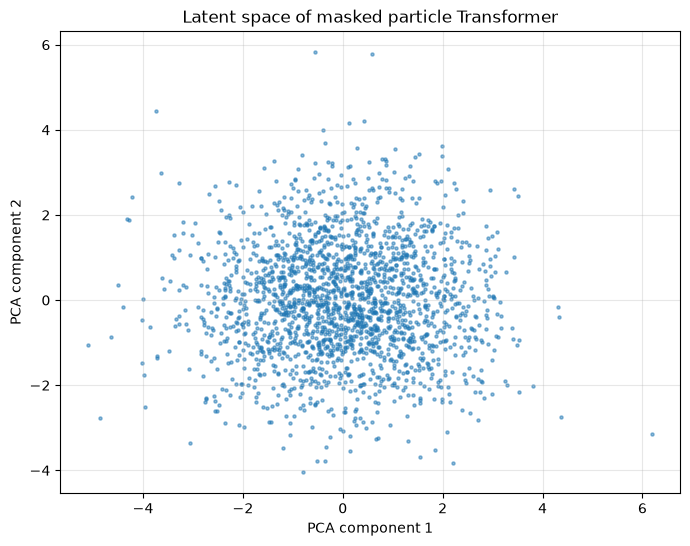

In [44]:
plt.figure(figsize=(8,6))


plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    s=5,
    alpha=0.5
)


plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.title(
    "Latent space of masked particle Transformer"
)

plt.grid(alpha=0.3)

plt.show()

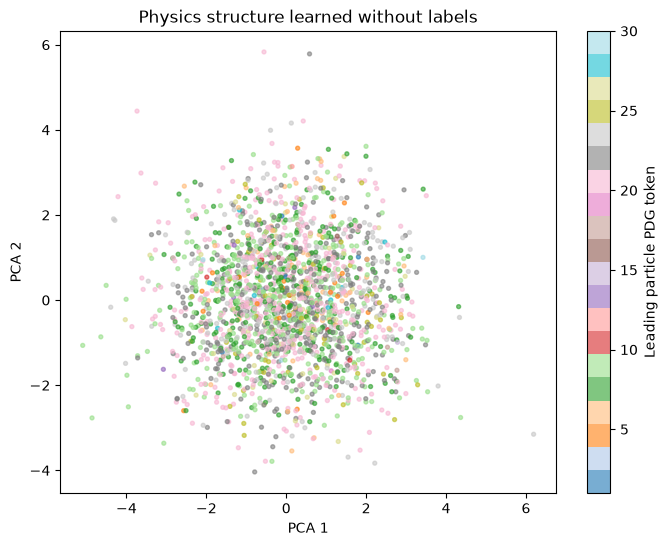

In [45]:
plt.figure(figsize=(8,6))


scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=val_labels.numpy(),
    s=8,
    alpha=0.6,
    cmap="tab20"
)


plt.colorbar(
    scatter,
    label="Leading particle PDG token"
)


plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title(
    "Physics structure learned without labels"
)

plt.show()

# Conclusion

In this notebook, a masked particle transformer was trained using a self-supervised
reconstruction objective.

The model learned particle-level representations by reconstructing masked particle
information without using physics labels during training.

The latent representation was visualized using PCA, showing that meaningful
structure can emerge from the learned embedding space.

This representation could be used for downstream physics tasks such as event
classification, anomaly detection, or particle identification.